In [ ]:
#| include: false
%config InlineBackend.figure_format = 'svg'

import pandas as pd
from pandas import DataFrame as df
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import numpy as np
import scipy.stats as stats

sns.set_theme(style="white", palette="muted")
wanted_labels = ["median_income", "median_house_value"]
dataset_full = pd.read_csv("./housing.csv")
dataset = dataset_full.filter(items=wanted_labels)

np.random.seed(3) # seed for determinism

# Probabilities and Statistics Term Project
## Dataset: California Housing prices
### Student ID: 26013429
### Full Name: PAKANDREI

Dataset Source:
https://www.kaggle.com/datasets/camnugent/california-housing-prices

Target variable: Median house value(median_house_value)

Predictor: Median income(median_income)

## Multivariate variables

| Variable name | Description |
| --- | --- |
| longitude | A measure of how far west a house is; a higher value is farther west |
| latitude | A measure of how far north a house is; a higher value is farther north |
| housing_median_age | Median age of a house within a block; a lower number is a newer building |
| total_rooms | Total number of rooms within a block |
| total_bedrooms | Total number of bedrooms within a block |
| population | Total number of people residing within a block |
| households | Total number of households, a group of people residing within a home unit, for a block |
| median_income | Median income for households within a block of houses (measured in tens of thousands of US Dollars) |
| median_house_value | Median house value for households within a block (measured in US Dollars) |
| ocean_proximity | Location of the house w.r.t ocean/sea |

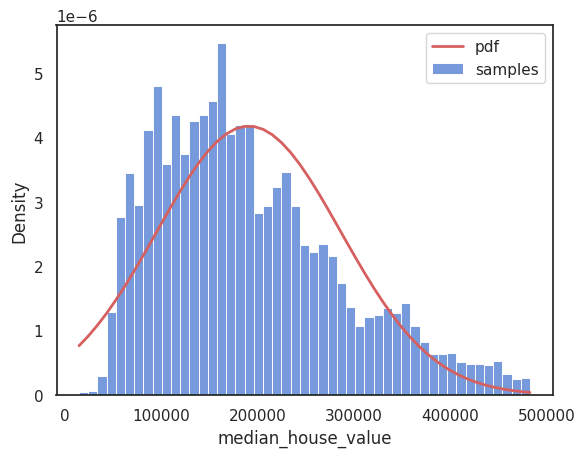

In [1862]:
# Boxplot of dataset before and after removing outliers
s1 = pd.Series(dataset['median_house_value'], name='Before')

q1 = s1.quantile(.25)
q3 = s1.quantile(.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = (s1 < lower) | (s1 > upper)

s2 = pd.Series(s1[~outliers], name='After')

df1 = pd.concat([s1, s2],axis=1)
sns.boxplot(df1, orient='v', order=['Before'], width=0.4)
sns.boxplot(df1, orient='v', order=['After'], width=0.4, whis=[0, 100])

dataset = dataset[~outliers] # set clean data for future cells

<Axes: >

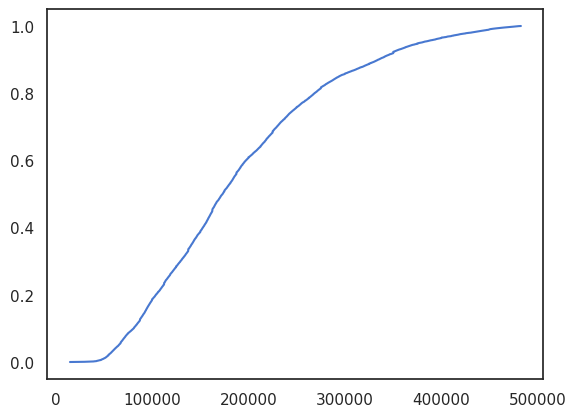

In [1863]:
# pdf and histplot
s1 = dataset['median_house_value']
vars = s1.describe()
g = sns.histplot(data=s1, stat='density',label='samples')

x = np.linspace(vars['min'], vars['max'])
y = stats.norm.pdf(x, vars['mean'], vars['std'])

g.plot(x, y, 'r', lw=2, label='pdf')
g.legend()

In [1864]:
# cdf
x, counts = np.unique(s1, return_counts=True, sorted=True)
events = np.cumsum(counts)
n = s1.size
cdf = events / n

sns.lineplot(x=x,y=cdf)

A = 3674, B = 2765
(A & B) = 1563
P(B | A) = P(A & B) / P(A)
P(B | A) ≈ 0.4254 or 42.54%


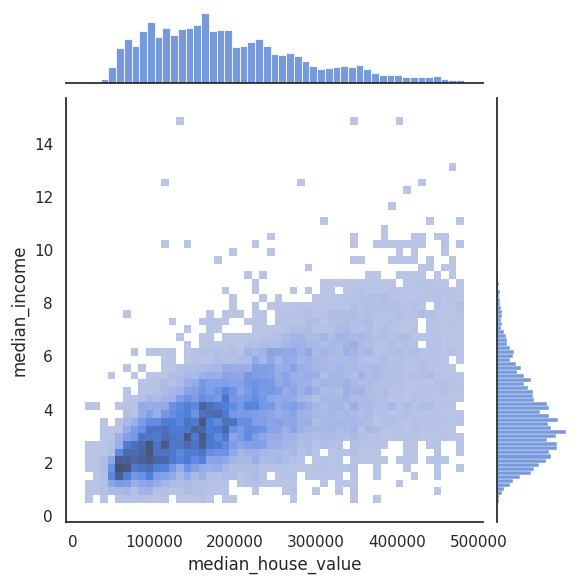

In [1865]:
# P(B|A) = P(A & B) / P(A),
# B = median_income > 10(100,000 US$),
# A = median_house_value > 300,000(US$)

df1 = dataset
a = df1["median_income"] > 5
b = df1["median_house_value"] > 300_000

cond = (a & b).sum() / a.sum()
print(f"A = {a.sum()}, B = {b.sum()}")
print(f"(A & B) = {(a & b).sum()}")
print("P(B | A) = P(A & B) / P(A)")
print(f"P(B | A) ≈ {cond:.4f} or {cond * 100:.2f}%")

<Axes: ylabel='Count'>

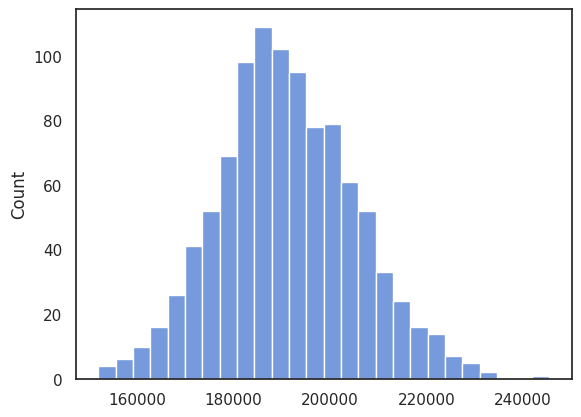

In [1866]:
#| code-fold: true
# heatmap
sns.jointplot(data=dataset, x="median_house_value", y="median_income",
              bins=50, kind='hist')

In [1867]:
vars = s1.describe()
mean = vars['mean']

# averages of 1000 random n=50 samples
sample_means = [s1.sample(n=50, replace=True).mean()
                for _ in range(1000)] 

sns.histplot(sample_means)

CI: [162400.0, 216900.0]


In [1868]:
# CI = x_hat +- z * (s / sqrt(n))
s = s1.sample(n=100)
confidence = .95
alpha = 1 - confidence

z = stats.norm.ppf(1 - alpha / 2)

lower = s.mean() - (z * s / np.sqrt(s.size))
upper = s.mean() + (z * s / np.sqrt(s.size))

ci = s[(s > lower) & (s < upper)]

print(f"""\
ci = x_hat +- z * (s / sqrt(n))
Confidence: {confidence * 100}%
CI: [{ci.min()}, {ci.max()}]\
""")
# FIXME: show plot with area shaded 

Fail to reject H_0
with p value = 0.4144270168231614 at 5.0% confidence level


In [ ]:
# h_0 = mu = mu_0vmin=50, vmax=100
# h_a mu > mu_0
mu_0 = s1.sample(n=1000).mean()
vars = s1.describe()

z = (vars['mean'] - mu_0) / (vars['std']  / np.sqrt(s1.size))

phi = stats.norm.cdf(abs(z))
p_value = 2 * (1 - phi)

confidence_level = 0.05
print(f"With p value = {p_value:2f} at {confidence_level * 100}% confidence level:")

print("\t", end="")
if p_value < confidence_level:
    print("Reject H_0")
else:
    print("Fail to reject H_0")

<Axes: >

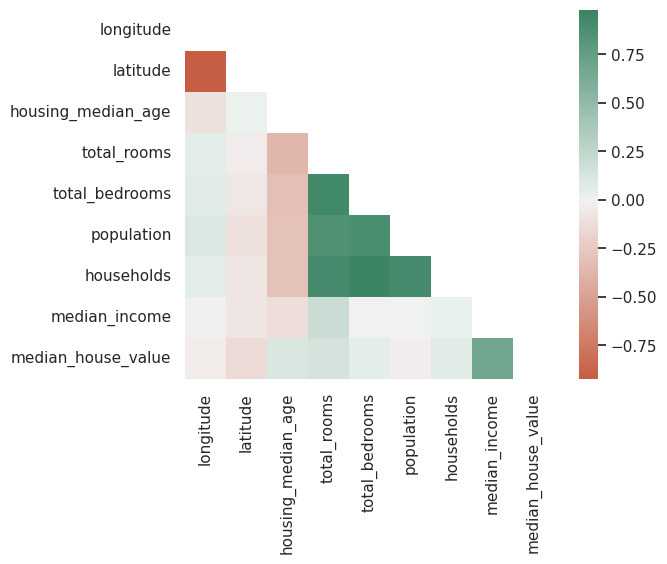

In [1869]:

corr = dataset_full.drop(['ocean_proximity'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(20, 150, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True)

In [1870]:
res = stats.linregress(dataset['median_house_value'], dataset['median_income'])
print(f"""\
Slope: {res.slope:.2f}
Intercept: {res.intercept:.2f}
R^2: {res.rvalue ** 2:.2f}\
""")

Slope: 0.00
Intercept: 1.66
R^2: 0.42



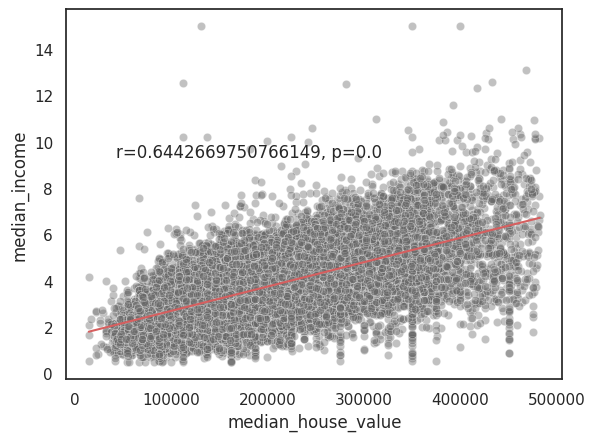

In [1871]:
x = dataset['median_house_value']
x_line = np.array([x.min(), x.max()])
y_line = res.intercept + res.slope*x_line

# little bit redundant, because r was calculated in cell above
r, p = stats.pearsonr(dataset['median_house_value'], dataset['median_income'])

g = sns.scatterplot(x=dataset['median_house_value'], y=dataset['median_income'],
                    alpha=0.4,color="0.4",edgecolor="w")
g.text(.1, .6,  f'r={r}, p={p}', transform=g.transAxes)
g.plot(x_line, y_line, color='r')